In [1]:
!pip install torch transformers pandas regex faiss-cpu numpy gradio sentence_transformers rouge-score bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 16.6 MB/s eta 0:00:00
   ━

In [6]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
import torch
import gradio as gr
from sklearn.preprocessing import normalize

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score

In [2]:
# Use MPNet-based embeddings
EMBEDDING_MODEL = "all-mpnet-base-v2"
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"
CHUNK_SIZE = 100
MIN_SIMILARITY = 0.7

# --------------------
# Preprocessing Function
# --------------------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --------------------
# Data Loading & Chunking
# --------------------
data = pd.read_csv("/Parts_processed.csv")
data = data[["ID", "DESCRIPTION"]].dropna()
data['clean_desc'] = data['DESCRIPTION'].apply(preprocess_text)

documents = []
metadata = []
for _, row in data.iterrows():
    text = f"ID {row['ID']}: {row['clean_desc']}"
    for i in range(0, len(text), CHUNK_SIZE):
        chunk = text[i:i+CHUNK_SIZE]
        documents.append(chunk)
        metadata.append({
            "id": row['ID'],
            "full_desc": row['DESCRIPTION'],
            "chunk_num": i // CHUNK_SIZE
        })

# --------------------
# Embedding & FAISS Index Creation
# --------------------
embedder = SentenceTransformer(EMBEDDING_MODEL)
doc_embeddings = embedder.encode(documents, show_progress_bar=True)
doc_embeddings = normalize(doc_embeddings).astype('float32')

index = faiss.IndexFlatIP(doc_embeddings.shape[1])
index.add(doc_embeddings)

id_to_docs = data.set_index('ID')['DESCRIPTION'].to_dict()

# --------------------
# LLM Setup for Generation
# --------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    temperature=0.7,
    max_new_tokens=256
)

# --------------------
# Search and Generation Functions
# --------------------
def find_similar_parts(query_id_or_text, k=5):
    # If the query is a numeric part ID, retrieve its description
    if str(query_id_or_text).isdigit() and int(query_id_or_text) in id_to_docs:
        query_text = preprocess_text(id_to_docs[int(query_id_or_text)])
    else:
        query_text = preprocess_text(query_id_or_text)

    # Embed the query and normalize
    query_embedding = embedder.encode([query_text])
    query_embedding = normalize(query_embedding).astype('float32')

    # Retrieve candidate chunks (requesting extra for threshold filtering)
    scores, indices = index.search(query_embedding, k * 2)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if score >= MIN_SIMILARITY:
            results.append({
                "id": metadata[idx]["id"],
                "score": score,
                "description": metadata[idx]["full_desc"]
            })

    # Deduplicate results by part ID and sort by similarity score descending
    seen = set()
    final_results = []
    for r in sorted(results, key=lambda x: -x['score']):
        if r['id'] not in seen:
            seen.add(r['id'])
            final_results.append(r)
            if len(final_results) >= k:
                break

    return final_results[:k]

def generate_answer(query):
    similar_parts = find_similar_parts(query)
    if not similar_parts:
        return "No similar parts found based on current data."

    # Build context string from the retrieved similar parts
    context = "\n".join(
        f"Part ID {p['id']} (similarity: {p['score']:.2f}): {p['description']}"
        for p in similar_parts
    )

    prompt = f"""<|system|>
You're a technical parts assistant. List similar parts based on this context:
{context}

<|user|>
Show similar parts for: {query}

<|assistant|>
"""
    response = generator(
        prompt,
        max_new_tokens=512,
        do_sample=True,
        num_beams=3
    )
    return response[0]['generated_text'].split("<|assistant|>")[-1].strip()

# --------------------
# (Optional) Evaluation Functions
# --------------------
evaluation_data = [
    {
        "query": "give me similar IDs of A1 based on description",
        "reference_answer": "Indicator Red Fast Movement 1.6A 250V Holder Plastic 5 X 20mm Ceramic Box CCC/PSE/VDE/cULus Electric Indicator, Very Fast Blow, 1.6A, 250VAC, 1500A (IR), Inline/holder, 5x20mm"
    },
    {
        "query": "give Red Fast Movement 1.6A 250V Holder Plastic IDs",
        "reference_answer": "Indicator Red Fast Movement 1.6A 250V Holder Plastic 5 X 20mm Ceramic Bulk CCC/CE/CSA/KC/PSE/SEMKO/UL/VDE Electric Indicator, Fast Blow, 1.6A, 250VAC, 1500A (IR), Inline/holder, 5x20mm"
    }
]

def evaluate_generation(evaluation_data):
    bleu_scores = []
    rouge_l_scores = []
    bert_f1_scores = []
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smoothing_function = SmoothingFunction().method1

    for example in evaluation_data:
        query = example["query"]
        reference = example["reference_answer"]
        generated = generate_answer(query)

        bleu = sentence_bleu([reference.split()], generated.split(), smoothing_function=smoothing_function)
        bleu_scores.append(bleu)

        rouge_scores = scorer.score(reference, generated)
        rouge_l_scores.append(rouge_scores['rougeL'].fmeasure)

        P, R, F1 = bert_score([generated], [reference], lang="en", verbose=False)
        bert_f1_scores.append(F1[0].item())

    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    avg_rouge_l = sum(rouge_l_scores) / len(rouge_l_scores)
    avg_bert_f1 = sum(bert_f1_scores) / len(bert_f1_scores)

    return avg_bleu, avg_rouge_l, avg_bert_f1

avg_bleu, avg_rouge_l, avg_bert_f1 = evaluate_generation(evaluation_data)
print("\nEvaluation Metrics:")
print(f" BLEU: {avg_bleu:.2f}")
print(f" ROUGE-L: {avg_rouge_l:.2f}")
print(f" BERTScore (F1): {avg_bert_f1:.2f}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluation Metrics:
 BLEU: 0.09
 ROUGE-L: 0.17
 BERTScore (F1): 0.83


In [7]:
# Gradio Code
def main():
  demo = gr.Interface(
      fn=generate_answer,
      inputs=gr.Textbox(label="Enter Part ID or Description"),
      outputs=gr.Textbox(label="Similar Parts"),
      title="Technical Parts Finder",
      description="Enter a Part ID or description to find similar components",
      examples=[["A1"], ["Attribute: VERY FAST"]]
  )

  demo.launch()

In [8]:
main()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e725e7a8c42286958c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


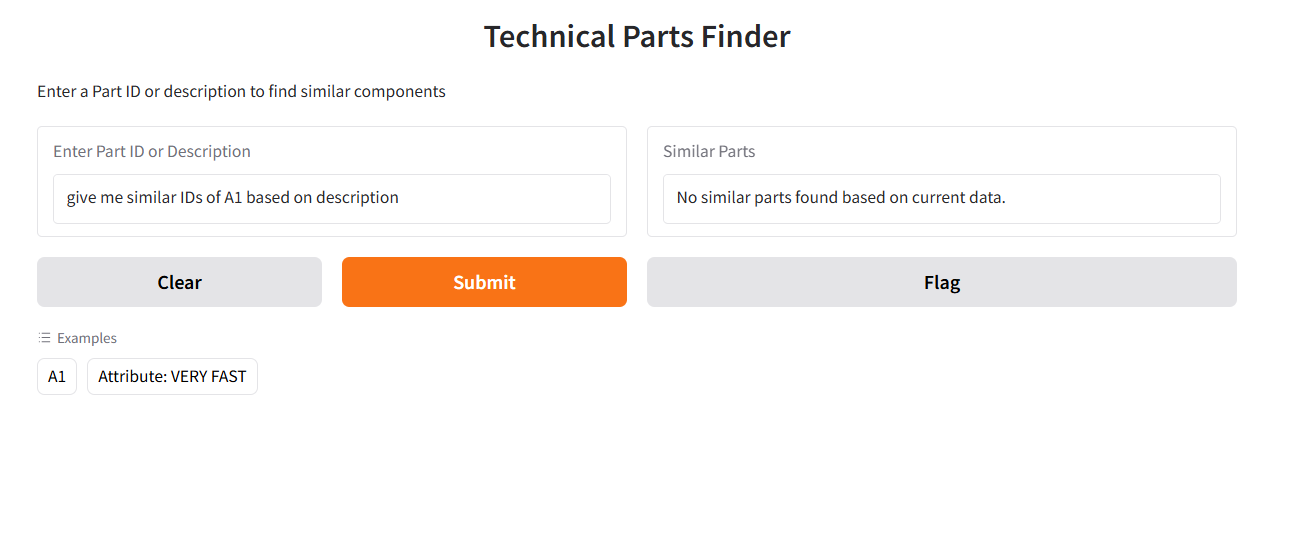

In [9]:
main()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0852ad9e20aae4729c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


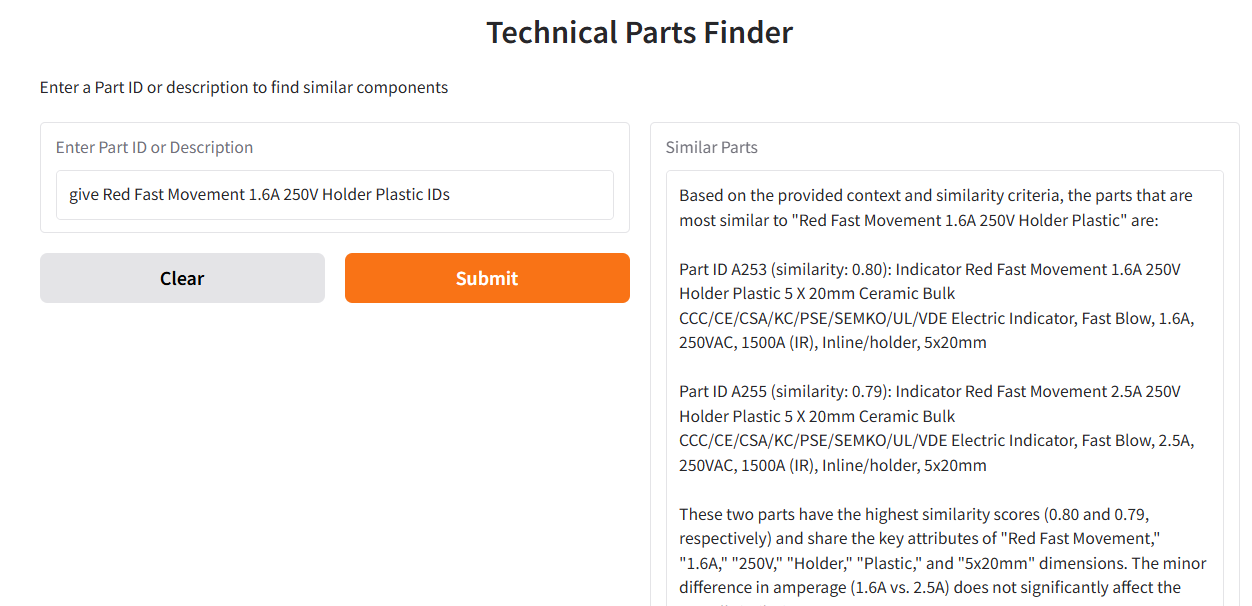